ISLES from final_adc_dataset_small

In [11]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
ISLES_adc_final_output_folder_registered = ROOT_DIR+"/datasets/final_adc_dataset_small/ISLES_registered/"
ISLES_masks_final_output_folder_registered = ROOT_DIR+"/datasets/final_adc_dataset_small/ISLES_masks_registered/"

In [ ]:


# Get all NIfTI files from both directories
adc_files = sorted([f for f in os.listdir(ISLES_adc_final_output_folder_registered) if f.endswith('.nii') or f.endswith('.nii.gz')])
mask_files = sorted([f for f in os.listdir(ISLES_masks_final_output_folder_registered) if f.endswith('.nii') or f.endswith('.nii.gz')])

# Plot middle axial slices
fig, axes = plt.subplots(len(adc_files), 2, figsize=(12, 4*len(adc_files)))
if len(adc_files) == 1:
    axes = axes.reshape(1, -1)

for i, (adc_file, mask_file) in enumerate(zip(adc_files, mask_files)):
    # Load ADC image
    adc_img = nib.load(os.path.join(ISLES_adc_final_output_folder_registered, adc_file))
    adc_data = adc_img.get_fdata()
    
    # Load mask image
    mask_img = nib.load(os.path.join(ISLES_masks_final_output_folder_registered, mask_file))
    mask_data = mask_img.get_fdata()
    
    # Get middle axial slice
    middle_slice = adc_data.shape[2] // 2
    
    # Plot ADC slice
    axes[i, 0].imshow(adc_data[:, :, middle_slice], cmap='gray')
    axes[i, 0].set_title(f'ADC: {adc_file}')
    axes[i, 0].axis('off')
    
    # Plot mask slice
    axes[i, 1].imshow(mask_data[:, :, middle_slice], cmap='jet')
    axes[i, 1].set_title(f'Mask: {mask_file}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [9]:
large_group_threshold = 450 # minimum size of the largest connected component to be considered in large group
medium_group_threshold = 100 # minimum size of the largest connected component to be considered in medium group
small_group_threshold = 10 # minimum size of the largest connected component to be considered in small group

large_group = []
medium_group = []
small_group = []

In [12]:
# distribute masks into groups based on the size of the largest connected component visible in the middle axial slice

from monai.transforms import KeepLargestConnectedComponent

# Initialize the transform
keep_largest = KeepLargestConnectedComponent()

# Count pixels in largest connected component for each mask
largest_component_sizes = []

for mask_file in tqdm(mask_files):
    # Load mask image
    mask_img = nib.load(os.path.join(ISLES_masks_final_output_folder_registered, mask_file))
    mask_data = mask_img.get_fdata()
    
    # Get middle axial slice
    middle_slice = mask_data.shape[2] // 2
    slice_data = mask_data[:, :, middle_slice]
    
    # Convert to binary mask
    binary_mask = slice_data > 0
    
    if np.any(binary_mask):
        # Apply MONAI's KeepLargestConnectedComponent
        largest_component = keep_largest(binary_mask.astype(np.float32))
        largest_component_size = int(np.sum(largest_component))
    else:
        largest_component_size = 0

    if largest_component_size >= large_group_threshold:
        large_group.append(mask_file)
    elif largest_component_size >= medium_group_threshold:
        medium_group.append(mask_file)
    elif largest_component_size >= small_group_threshold:
        small_group.append(mask_file)
    
    largest_component_sizes.append(largest_component_size)
    #print(f"{mask_file}: {largest_component_size} pixels in largest component")

print(f"\nSummary:")
print(f"Mean largest component size: {np.mean(largest_component_sizes):.2f}")
print(f"Max largest component size: {np.max(largest_component_sizes)}")
print(f"Min largest component size: {np.min(largest_component_sizes)}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:07<00:00, 32.26it/s]


Summary:
Mean largest component size: 158.01
Max largest component size: 3404
Min largest component size: 0


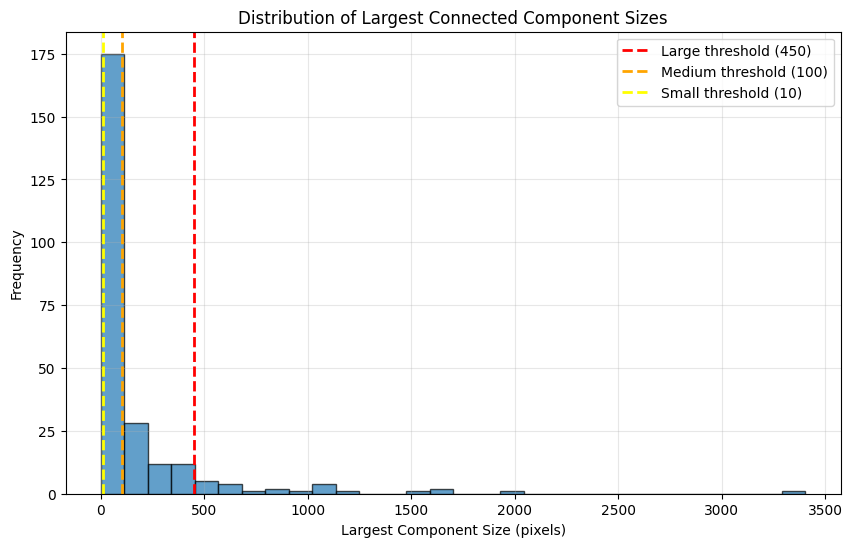

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(largest_component_sizes, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(large_group_threshold, color='red', linestyle='--', linewidth=2, label=f'Large threshold ({large_group_threshold})')
plt.axvline(medium_group_threshold, color='orange', linestyle='--', linewidth=2, label=f'Medium threshold ({medium_group_threshold})')
plt.axvline(small_group_threshold, color='yellow', linestyle='--', linewidth=2, label=f'Small threshold ({small_group_threshold})')
plt.xlabel('Largest Component Size (pixels)')
plt.ylabel('Frequency')
plt.title('Distribution of Largest Connected Component Sizes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
print(large_group)
print(medium_group)
print(small_group)

['sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.